In [172]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp
import yfinance as yf

In [173]:
class NextGenReservoirComputing:
    def __init__(self, d, k, warmup_pts):
        self.d = d
        self.k = k
        self.dlin = k*d                             # Size of the O_{linear} part
        self.dnonlin = int(dlin*(dlin+1)/2)         # Size of the O_{nonlinear} part
        self.dtot = 1 + dlin + dnonlin              # total dimension of O_{total}
        self.warmup_pts = warmup_pts

    def train(self, x_data, traintime_pts):
        self.warmtrain_pts = warmup_pts + traintime_pts
        self.x = np.zeros((dlin, len(x_data[0])-1))
        self.out_train = np.ones((dtot, traintime_pts))

        for delay in range(k):                       # Adding the linear part to dimensions [1:7]
            for j in range(delay,len(x_data[0])-1):
                self.x[(d*delay):(d*(delay+1)),j] = x_data[:, j-delay]
        self.out_train[1:dlin+1,:] = self.x[:, warmup_pts-1:warmtrain_pts-1]

        count = 0
        for row in range(dlin):
            for column in range(row,dlin):          # Adding the non-linear part to dimensions [8:28]
              self.out_train[dlin+1+count] = self.x[row, warmup_pts-1:warmtrain_pts-1] * self.x[column, warmup_pts-1:warmtrain_pts-1]
              count += 1

        self.W_out = ridge_regression(self.out_train, x_data, d, warmup_pts, warmtrain_pts)

    def test(self, testtime_pts):
        out_test = np.zeros(dtot)
        x_test = np.zeros((dlin, testtime_pts))
        x_test[:, 0] = self.x[:, self.warmtrain_pts-1]

        for j in range(testtime_pts-1):
          out_test[1:dlin+1] = x_test[:, j]
          count=0
          for row in range(dlin):
            for column in range(row, dlin):
              out_test[dlin+1+count] = x_test[row, j] * x_test[column, j]
              count += 1

          x_test[d:dlin, j+1] = x_test[0:(dlin-d), j]
          x_test[0:d, j+1] = x_test[0:d, j] + self.W_out @ out_test[:]

        return x_test

In [174]:
def ridge_regression(out_train, x, d, warmup_pts, warmtrain__pts):
    ridge_param = 0.25
    W_out = (x[0:d, warmup_pts:warmtrain_pts] - x[0:d, warmup_pts-1:warmtrain_pts-1])  @ out_train[:,:].T @ np.linalg.pinv(out_train[:,:] @ out_train[:,:].T + ridge_param*np.identity(dtot))
    return W_out  # obtained the ideal weight matrix

In [175]:
# Parameters for data points

dt = 0.025
warmup = 5                                            # The data points before this are not considered
traintime = 20                                         # The NG-RC is trained till this data point
testtime = 120                                        # The NG-RC is tested till this data point
maxtime = warmup + traintime + testtime                # Maximum data point
plottime = 20                                          # The data point till which plotting takes place
lyaptime = 1.104

# Discrete - time versions of the times defined above
warmup_pts    = round(warmup/dt)
traintime_pts = round(traintime/dt)
warmtrain_pts = warmup_pts + traintime_pts
testtime_pts  = round(testtime/dt)
maxtime_pts   = round(maxtime/dt)
plottime_pts  = round(plottime/dt)
lyaptime_pts  = round(lyaptime/dt)

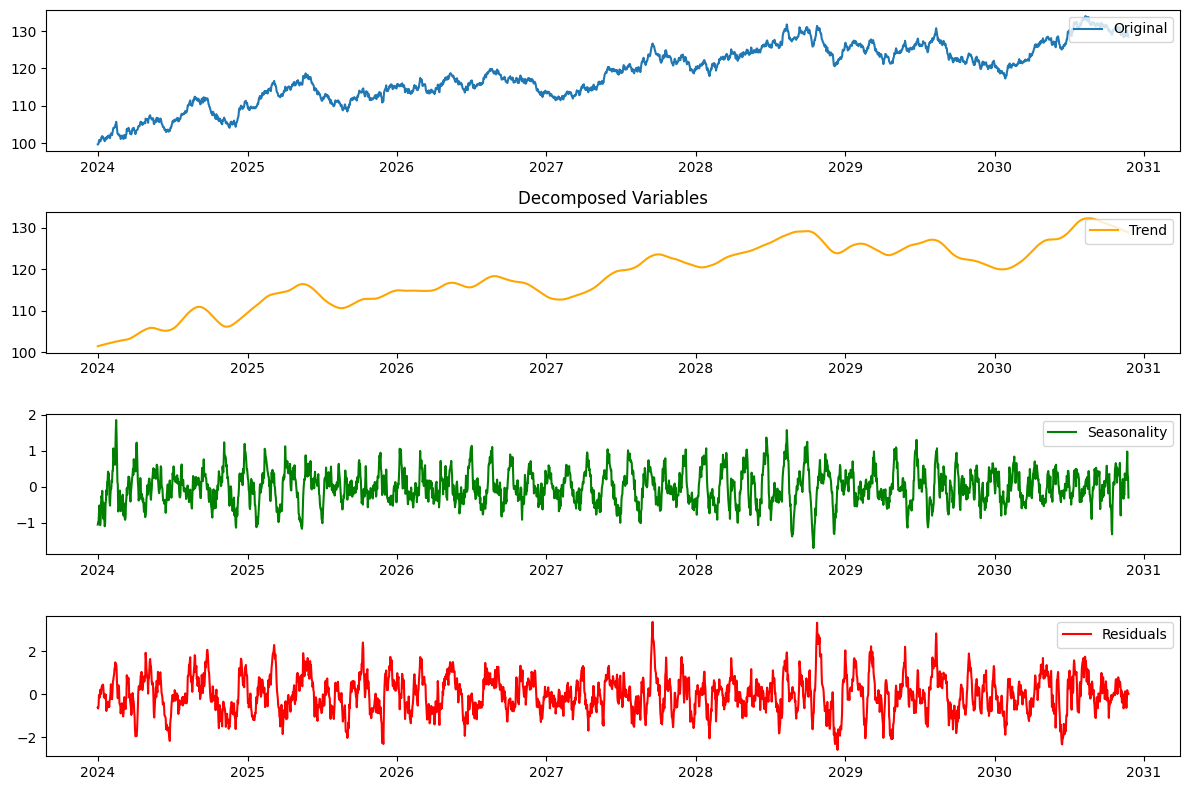

In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

np.random.seed(75)

def simulate_gbm(S0, mu, sigma, T, N):
    dt = T / N
    t = np.linspace(0, T, N)
    W = np.random.standard_normal(size=N)
    W = np.cumsum(W) * np.sqrt(dt)  # Brownian motion
    X = (mu - 0.5 * sigma**2) * t + sigma * W
    S = S0 * np.exp(X)
    return pd.Series(S, index=pd.date_range(start='2024-01-01', periods=N))

# Parameters
S0 = 100      # initial stock price
mu = 0.1      # drift
sigma = 0.2   # volatility
T = 1         # 1 year
N = 252 * 10     # number of trading days

stock_prices = simulate_gbm(S0, mu, sigma, T, N)
stock_prices.name = "GBM Simulated Price"

stl = STL(stock_prices, period=50)  # roughly 1 month period
result = stl.fit()

trend = result.trend
seasonal = result.seasonal
resid = result.resid


plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(stock_prices, label="Original")
plt.legend(loc='upper right')

plt.subplot(4, 1, 2)
plt.plot(trend, label="Trend", color='orange')
plt.title("Decomposed Variables")
plt.legend(loc='upper right')

plt.subplot(4, 1, 3)
plt.plot(seasonal, label="Seasonality", color='green')
plt.legend(loc='upper right')

plt.subplot(4, 1, 4)
plt.plot(resid, label="Residuals", color='red')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


In [177]:
# # Download 10 years of Apple stock data
# aapl_data = yf.download('AAPL', start='2014-06-24', end='2024-06-24')

# # Select only the 'Close' column and drop any NaN values
# aapl_close = aapl_data['Close'].dropna()

# # Display the first few rows
# print(aapl_close.head())


# stock_prices=np.array([aapl_close])

# stl = STL(stock_prices, period=50)  # roughly 1 month period
# result = stl.fit()

# trend = result.trend
# seasonal = result.seasonal
# resid = result.resid


# plt.figure(figsize=(12, 8))

# plt.subplot(4, 1, 1)
# plt.plot(stock_prices, label="Original")
# plt.legend(loc='upper right')

# plt.subplot(4, 1, 2)
# plt.plot(trend, label="Trend", color='orange')
# plt.title("Decomposed Variables")
# plt.legend(loc='upper right')

# plt.subplot(4, 1, 3)
# plt.plot(seasonal, label="Seasonality", color='green')
# plt.legend(loc='upper right')

# plt.subplot(4, 1, 4)
# plt.plot(resid, label="Residuals", color='red')
# plt.legend(loc='upper right')

# plt.tight_layout()
# plt.show()

In [178]:
seasonal

2024-01-01   -1.057198
2024-01-02   -0.995919
2024-01-03   -0.992101
2024-01-04   -0.711733
2024-01-05   -0.524136
                ...   
2030-11-20    0.585805
2030-11-21    0.976995
2030-11-22    0.346626
2030-11-23    0.259191
2030-11-24   -0.306384
Freq: D, Name: season, Length: 2520, dtype: float64

In [179]:
x = np.expand_dims(seasonal,axis=0)
x.shape

(1, 2520)

In [180]:
x

array([[-1.05719809, -0.99591861, -0.9921014 , ...,  0.34662644,
         0.25919084, -0.30638424]])

In [181]:
# input dimensions
d = 1                                  # dimension of input parameters
k = 25                               # there are two delay values 0 and 1, s is taken as 1 here
dlin = k*d                             # size of the O_{linear} part
dnonlin = int(dlin*(dlin+1)/2)         # size of the O_{nonlinear} part
dtot = 1 + dlin + dnonlin              # total dimension of O_{total}

# Training the NGRC
NGRC = NextGenReservoirComputing(d, k, warmup_pts)
NGRC.train(x, traintime_pts)
x_predict = x[0:d,warmup_pts-1:warmtrain_pts-1] + NGRC.W_out @ NGRC.out_train[:,0:traintime_pts]
nrmse = np.sqrt(np.mean((x[0:d,warmup_pts:warmtrain_pts]-x_predict[:,:])**2))
print('training nrmse:'+str(nrmse))

# Predicting the lorenz63 data
x_test = NGRC.test(testtime_pts)
test_nrmse = np.sqrt(np.mean((x[0:d,warmtrain_pts-1:warmtrain_pts+lyaptime_pts-1]-x_test[0:d,0:lyaptime_pts])**2))
print('test nrmse:' + str(test_nrmse))

training nrmse:0.10997221090225208
test nrmse:0.29787162033409387


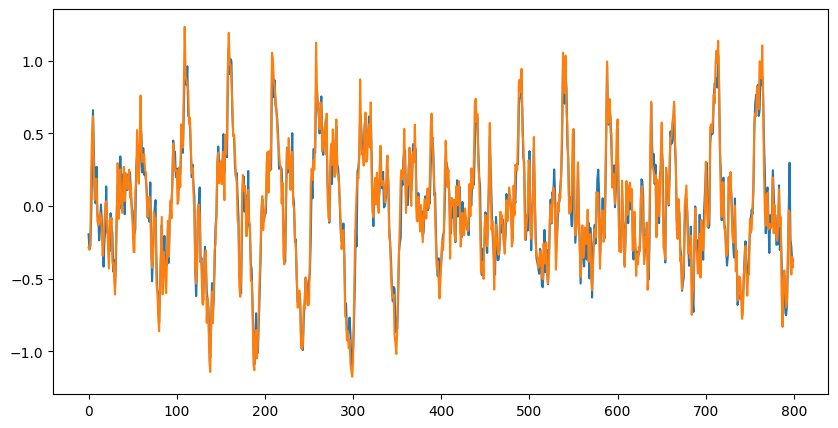

In [182]:
plt.figure(figsize=(10,5))
plt.plot(x_predict[0:d,0:plottime_pts].T)
plt.plot(x[0:d,warmup_pts:warmtrain_pts].T)

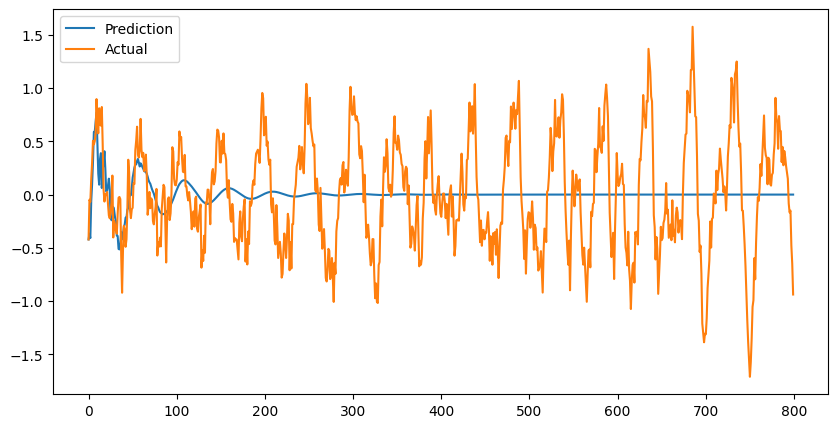

In [183]:
plt.figure(figsize=(10,5))
plt.plot(x_test[0:d,0:plottime_pts].T,label='Prediction')
plt.plot(x[0:d,warmtrain_pts-1:warmtrain_pts+plottime_pts-1].T,label='Actual')
plt.legend()

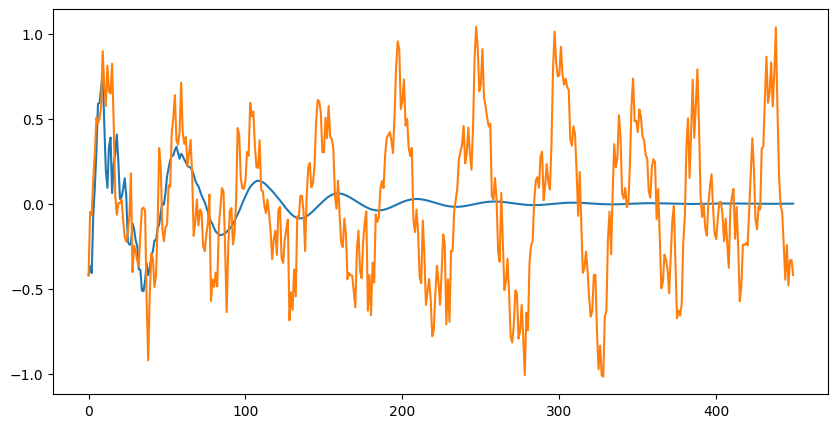

In [184]:
plt.figure(figsize=(10,5))
plt.plot(x_test[0:d,0:450].T)
plt.plot(x[0:d,warmtrain_pts-1:warmtrain_pts+450-1].T)